In [120]:
#Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, silhouette_score, roc_auc_score, accuracy_score

In [121]:
#Importing dataset
data = pd.read_csv('Nigeria_Crop_Disease.csv')
print("Dataframe shape:", data.shape)
data.head(10)

Dataframe shape: (2250, 12)


,Disease_Class,Geopolitical_Zone,Eco_Zone,Soil_Type,Rainfall_mm,Temperature_C,Relative_Humidity_Pct,Nitrogen_Level_ppm,Phosphorus_Level_ppm,Potassium_Level_ppm,Insect_Vector_Count,Leaf_Symptom_Severity
0,Fungal_Blight,South_South,Humid_Forest,Lateritic,1800.0,30.8,91.8,90.0,45.0,180.0,8,4
1,Healthy,North_West,Derived_Savanna,Alluvial,1571.0,32.0,65.4,93.6,38.0,115.8,0,1
2,Fungal_Blight,South_East,Humid_Forest,Clay_Loam,2422.7,34.2,82.2,90.0,45.0,180.0,4,5
3,Healthy,South_West,Derived_Savanna,Sandy_Loam,1110.5,24.1,51.2,62.0,40.2,163.8,1,1
4,Viral_Mosaic,South_West,Derived_Savanna,Clay_Loam,1165.9,30.1,59.3,100.0,55.0,220.0,25,3
5,Viral_Mosaic,South_West,Southern_Guinea_Savanna,Clay_Loam,818.6,32.1,60.7,100.0,55.0,220.0,20,3
6,Nutrient_Deficiency,North_East,Southern_Guinea_Savanna,Sandy_Loam,845.0,34.1,66.6,18.6,11.7,69.3,0,2
7,Healthy,North_West,Southern_Guinea_Savanna,Sandy_Loam,1268.1,28.2,54.6,76.8,39.2,156.8,2,1
8,Viral_Mosaic,North_Central,Derived_Savanna,Alluvial,1216.0,31.5,68.2,100.0,55.0,220.0,26,3
9,Bacterial_Wilt,North_East,Derived_Savanna,Clay_Loam,853.9,32.8,77.1,100.0,55.0,220.0,8,4


In [123]:
#Checking the data types of each column
print("Data types:", data.dtypes)
#Checking for missing values in the dataset
print("\n        Missing Values:       ")
print(data.isnull().sum() * 100)

Data types: Disease_Class                str
Geopolitical_Zone            str
Eco_Zone                     str
Soil_Type                    str
Rainfall_mm              float64
Temperature_C            float64
Relative_Humidity_Pct    float64
Nitrogen_Level_ppm       float64
Phosphorus_Level_ppm     float64
Potassium_Level_ppm      float64
Insect_Vector_Count        int64
Leaf_Symptom_Severity      int64
dtype: object

        Missing Values:       
Disease_Class            0
Geopolitical_Zone        0
Eco_Zone                 0
Soil_Type                0
Rainfall_mm              0
Temperature_C            0
Relative_Humidity_Pct    0
Nitrogen_Level_ppm       0
Phosphorus_Level_ppm     0
Potassium_Level_ppm      0
Insect_Vector_Count      0
Leaf_Symptom_Severity    0
dtype: int64


In [124]:
# One-hot encode nominal categoricals (no ordinal relationship)
data = pd.get_dummies(data, columns=['Geopolitical_Zone', 'Eco_Zone', 'Soil_Type'], 
                      drop_first=False, dtype=int)

# Encode target variable
le = LabelEncoder()
data['Disease_Class_Encoded'] = le.fit_transform(data['Disease_Class'])

# Print mapping
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Target encoding mapping:", mapping)

# Dropping original string target
data = data.drop(columns=['Disease_Class'])

print(data.shape)
data.head()

Target encoding mapping: {'Bacterial_Wilt': np.int64(0), 'Fungal_Blight': np.int64(1), 'Healthy': np.int64(2), 'Nutrient_Deficiency': np.int64(3), 'Viral_Mosaic': np.int64(4)}
(2250, 23)


,Rainfall_mm,Temperature_C,Relative_Humidity_Pct,Nitrogen_Level_ppm,Phosphorus_Level_ppm,Potassium_Level_ppm,Insect_Vector_Count,Leaf_Symptom_Severity,Geopolitical_Zone_North_Central,Geopolitical_Zone_North_East,...,Geopolitical_Zone_South_West,Eco_Zone_Derived_Savanna,Eco_Zone_Humid_Forest,Eco_Zone_Southern_Guinea_Savanna,Eco_Zone_Sudan_Savanna,Soil_Type_Alluvial,Soil_Type_Clay_Loam,Soil_Type_Lateritic,Soil_Type_Sandy_Loam,Disease_Class_Encoded
0,1800.0,30.8,91.8,90.0,45.0,180.0,8,4,0,0,...,0,0,1,0,0,0,0,1,0,1
1,1571.0,32.0,65.4,93.6,38.0,115.8,0,1,0,0,...,0,1,0,0,0,1,0,0,0,2
2,2422.7,34.2,82.2,90.0,45.0,180.0,4,5,0,0,...,0,0,1,0,0,0,1,0,0,1
3,1110.5,24.1,51.2,62.0,40.2,163.8,1,1,0,0,...,1,1,0,0,0,0,0,0,1,2
4,1165.9,30.1,59.3,100.0,55.0,220.0,25,3,0,0,...,1,1,0,0,0,0,1,0,0,4


Disease_Class_Encoded
2    575
1    525
0    400
4    375
3    375
Name: count, dtype: int64


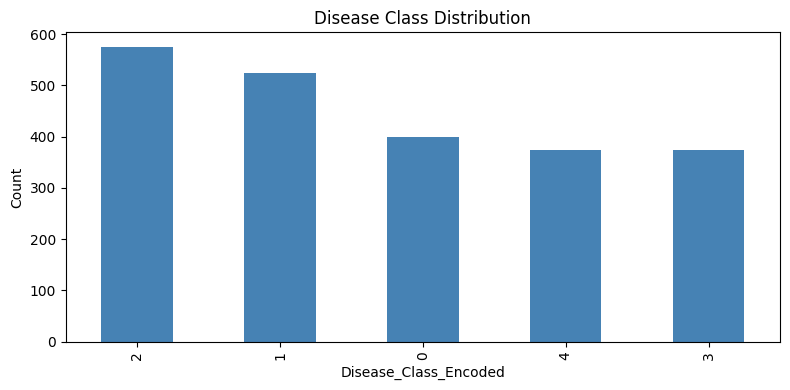

Imbalance ratio (max/min): 1.53


In [125]:
#Checking the distribution of the target variable 'Disease_Class'
print(data['Disease_Class_Encoded'].value_counts())

#Visualizing the distribution of the target variable
plt.figure(figsize=(8, 4))
data['Disease_Class_Encoded'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Disease Class Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
imbalance_ratio = data['Disease_Class_Encoded'].value_counts().max() / data['Disease_Class_Encoded'].value_counts().min()
print("Imbalance ratio (max/min):", round(imbalance_ratio, 2))


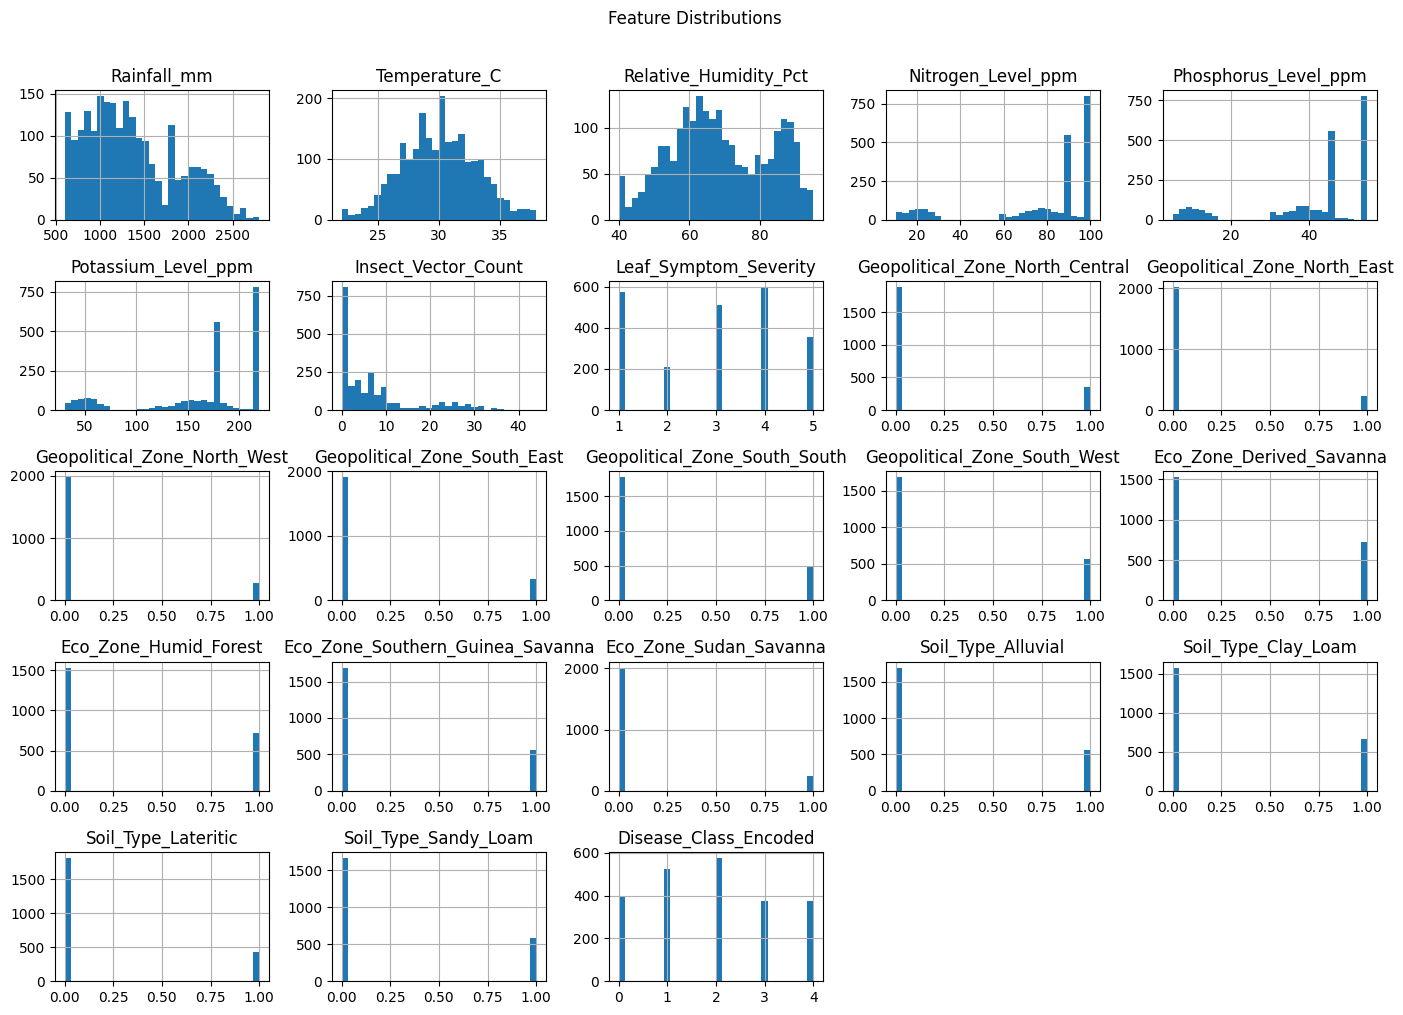

In [126]:
#Visualizing the distribution of numerical features
data.hist(figsize=(14, 10), bins=30)
plt.suptitle('Feature Distributions', y=1.01)
plt.tight_layout()
plt.show()

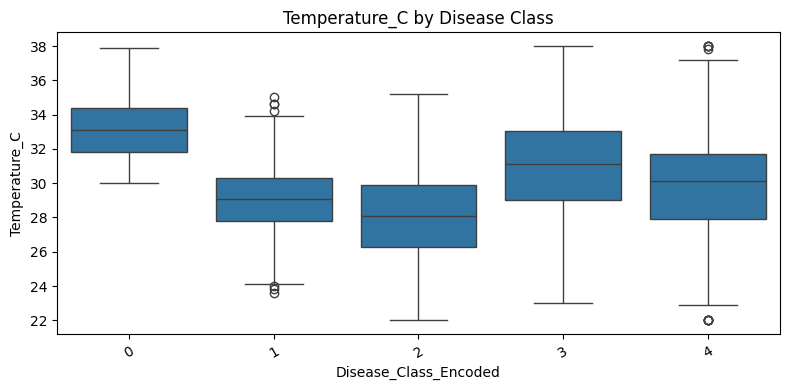

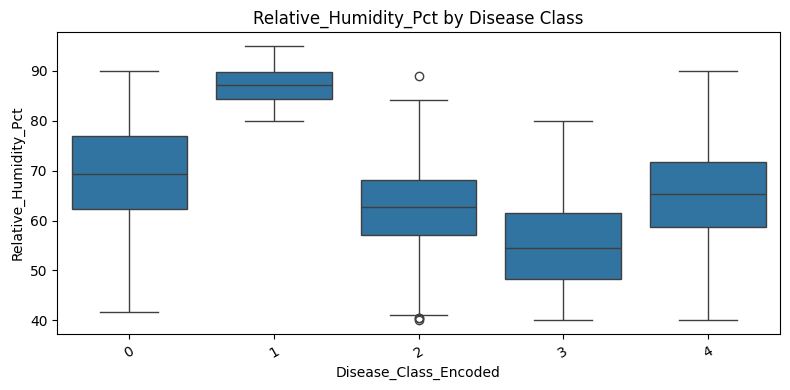

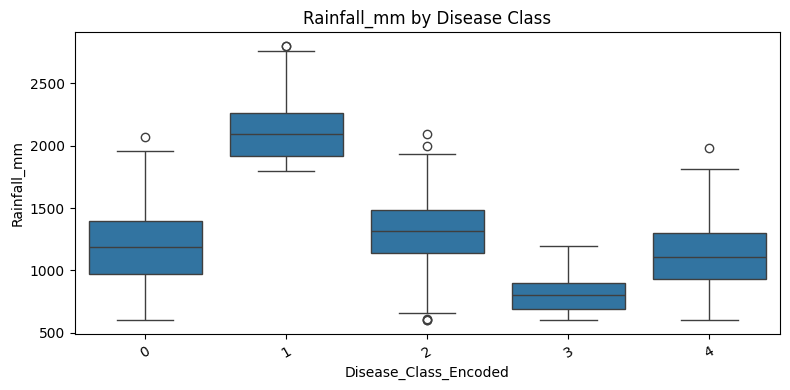

In [129]:
#Visualizing the relationship between features and the target variable using boxplots (Bivariate analysis)
for feat in ['Temperature_C', 'Relative_Humidity_Pct', 'Rainfall_mm']:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x='Disease_Class_Encoded', y=feat, data=data)
    plt.title(f'{feat} by Disease Class')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

In [130]:
#Getting the summary statistics of the dataset from the float and int columns (the numerical columns)
data.describe()

,Rainfall_mm,Temperature_C,Relative_Humidity_Pct,Nitrogen_Level_ppm,Phosphorus_Level_ppm,Potassium_Level_ppm,Insect_Vector_Count,Leaf_Symptom_Severity,Geopolitical_Zone_North_Central,Geopolitical_Zone_North_East,...,Geopolitical_Zone_South_West,Eco_Zone_Derived_Savanna,Eco_Zone_Humid_Forest,Eco_Zone_Southern_Guinea_Savanna,Eco_Zone_Sudan_Savanna,Soil_Type_Alluvial,Soil_Type_Clay_Loam,Soil_Type_Lateritic,Soil_Type_Sandy_Loam,Disease_Class_Encoded
count,2250.000000,2250.000000,2250.000000,2250.000000,2250.000000,2250.000000,2250.000000,2250.000000,2250.000000,2250.000000,...,2250.000000,2250.000000,2250.00000,2250.000000,2250.000000,2250.000000,2250.000000,2250.000000,2250.000000,2250.000000
mean,1358.287867,30.020444,68.698356,78.701022,41.097689,166.944222,7.266222,2.976889,0.160444,0.102667,...,0.251556,0.323556,0.32000,0.248889,0.107556,0.247556,0.298222,0.194222,0.260000,1.911111
std,506.928863,3.052996,13.821457,28.102061,15.361377,58.844502,8.882903,1.418107,0.367099,0.303590,...,0.434004,0.467937,0.46658,0.432465,0.309887,0.431688,0.457579,0.395689,0.438732,1.330663
min,600.000000,22.000000,40.000000,10.000000,5.000000,30.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,960.825000,27.900000,58.600000,73.425000,36.825000,149.625000,1.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,1270.850000,30.000000,67.150000,90.000000,45.000000,180.000000,4.000000,3.000000,0.000000,0.000000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,1776.600000,32.100000,81.200000,100.000000,55.000000,220.000000,9.000000,4.000000,0.000000,0.000000,...,1.000000,1.000000,1.00000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,3.000000
max,2800.000000,38.000000,95.000000,100.000000,55.000000,220.000000,44.000000,5.000000,1.000000,1.000000,...,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,4.000000


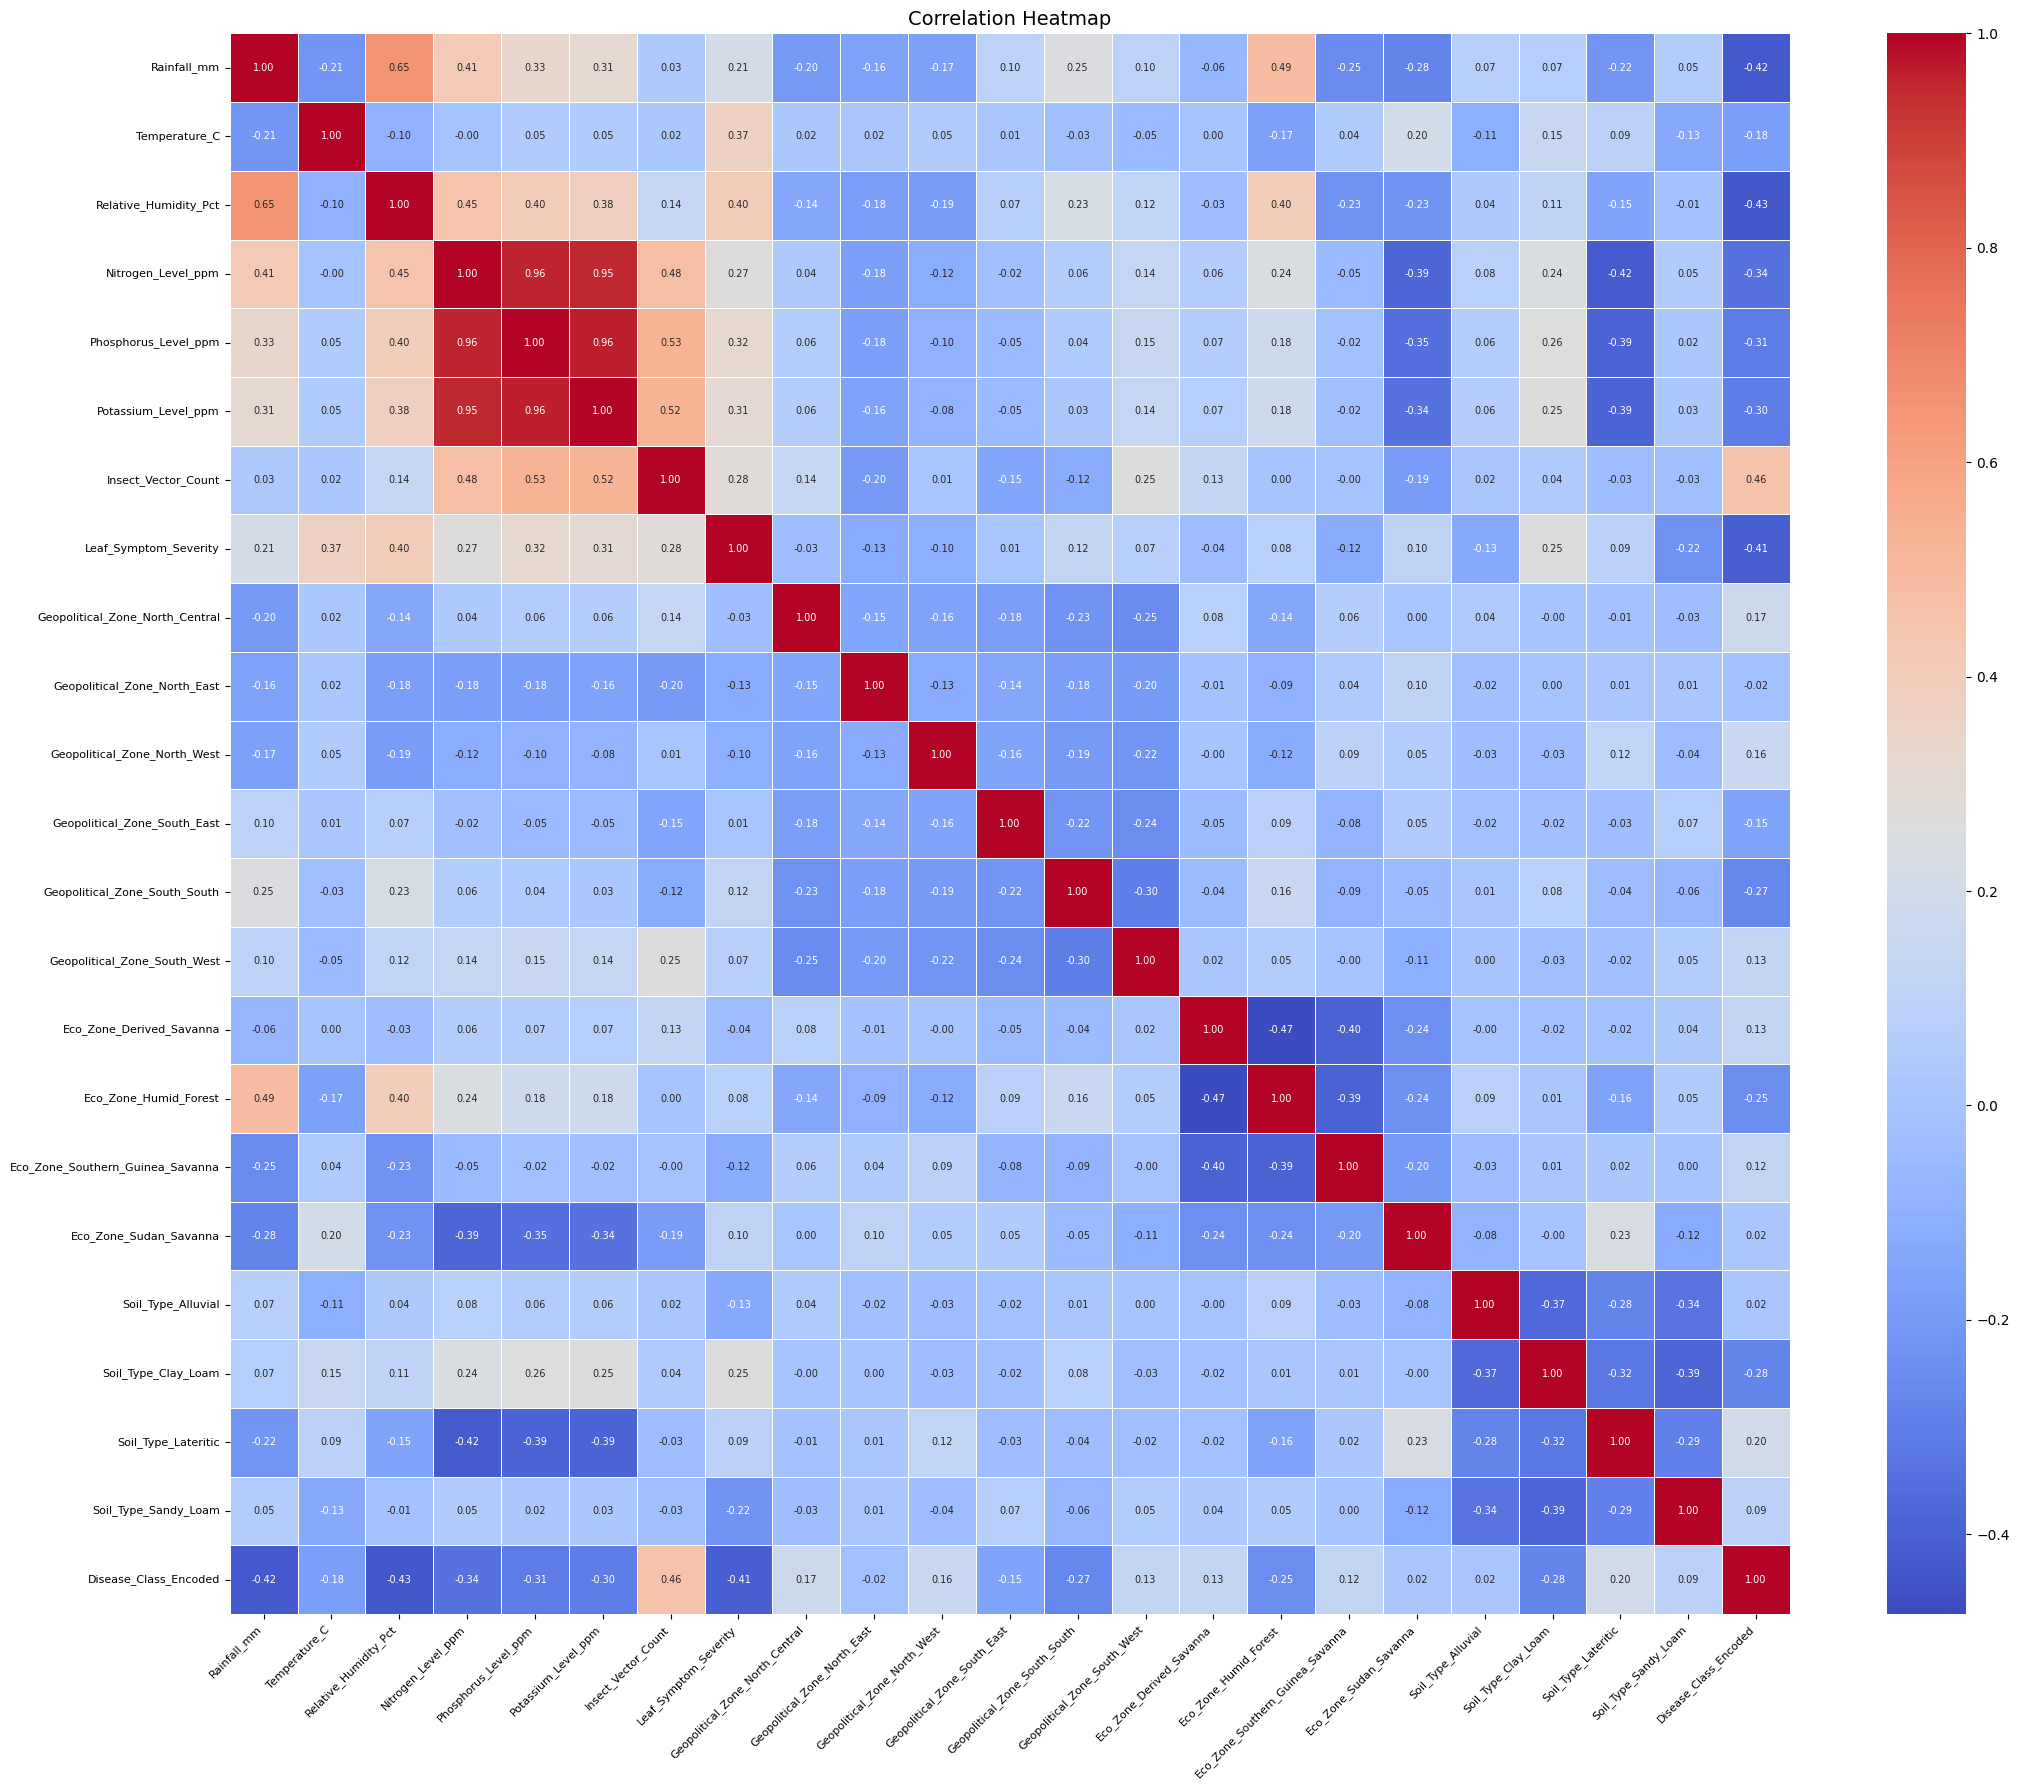

In [132]:
#Correlation heatmap to visualize relationships between numerical features
corr_matrix = data.corr()
plt.figure(figsize=(22, 18))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', 
            fmt='.2f', annot_kws={'size': 7},
            linewidths=0.5, linecolor='white')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

In [133]:
outlier_report = []
num_cols = data.select_dtypes(include=['number']).columns
for col in num_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Count how many rows fall outside the boundaries
    outlier_count = data[(data[col] < lower_bound) | (data[col] > upper_bound)].shape[0]
    outlier_pct = (outlier_count / data.shape[0]) * 100
    
    outlier_report.append({
        'Column': col,
        'Outlier Count': outlier_count,
        'Percentage (%)': round(outlier_pct, 2),
        'Lower Bound': round(lower_bound, 2),
        'Upper Bound': round(upper_bound, 2)
    })

# Convert the results into a clean, scannable DataFrame
report_df = pd.DataFrame(outlier_report)
print(report_df.to_string(index=False))

                          Column  Outlier Count  Percentage (%)  Lower Bound  Upper Bound
                     Rainfall_mm              0            0.00      -262.84      3000.26
                   Temperature_C              0            0.00        21.60        38.40
           Relative_Humidity_Pct              0            0.00        24.70       115.10
              Nitrogen_Level_ppm            375           16.67        33.56       139.86
            Phosphorus_Level_ppm            166            7.38         9.56        82.26
             Potassium_Level_ppm            117            5.20        44.06       325.56
             Insect_Vector_Count            276           12.27       -11.00        21.00
           Leaf_Symptom_Severity              0            0.00        -3.50         8.50
 Geopolitical_Zone_North_Central            361           16.04         0.00         0.00
    Geopolitical_Zone_North_East            231           10.27         0.00         0.00
    Geopol

In [134]:
#Separating features and target variable for modeling
x = data.drop(columns=['Disease_Class_Encoded']).values
y = data['Disease_Class_Encoded'].values

In [135]:
print(x)
print(y)

[[1.8000e+03 3.0800e+01 9.1800e+01 ... 0.0000e+00 1.0000e+00 0.0000e+00]
 [1.5710e+03 3.2000e+01 6.5400e+01 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [2.4227e+03 3.4200e+01 8.2200e+01 ... 1.0000e+00 0.0000e+00 0.0000e+00]
 ...
 [1.3579e+03 3.0600e+01 8.4300e+01 ... 1.0000e+00 0.0000e+00 0.0000e+00]
 [1.9426e+03 3.5500e+01 6.0800e+01 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [1.9300e+03 2.4800e+01 8.6300e+01 ... 0.0000e+00 0.0000e+00 0.0000e+00]]
[1 2 1 ... 0 0 1]


In [136]:
#Splitting the dataset into training and test sets with stratification to maintain class distribution
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
print("Training set shape:", x_train.shape)
print("Test set shape:", x_test.shape)
print("Training labels shape:", y_train.shape)
print("Test labels shape:", y_test.shape)

Training set shape: (1800, 22)
Test set shape: (450, 22)
Training labels shape: (1800,)
Test labels shape: (450,)


In [137]:
# 3. Initialize and fit the LDA model
lda = LinearDiscriminantAnalysis()
lda.fit(x_train, y_train)

,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None


In [138]:
# 4. Evaluate or transform the data
accuracy = lda.score(x_test, y_test)
print(f"LDA Test Accuracy: {accuracy:.4f}")

LDA Test Accuracy: 0.9978


In [139]:
# Optional: Transform data to reduced feature space (dimensionality reduction)
# Max components is min(n_features, n_classes - 1)
x_train_lda = lda.transform(x_train)

In [140]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
x_transform = scaler.transform(x)
print(x_transform.shape)
print(x_scaled.shape)

(2250, 22)
(2250, 22)


In [141]:
#testing different k values for k-means, and storing the inertia values for each k
k_range = range(2, 11)
inertias = []
for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=300, random_state=42)
    km.fit(x_transform)
    inertias.append(km.inertia_)
    print(f'k={k:2d}, inertia: {km.inertia_:.2f}')

k= 2, inertia: 41174.63
k= 3, inertia: 37002.26
k= 4, inertia: 33279.93
k= 5, inertia: 31283.40
k= 6, inertia: 30132.51
k= 7, inertia: 28952.48
k= 8, inertia: 27703.45
k= 9, inertia: 26619.61
k=10, inertia: 25650.27


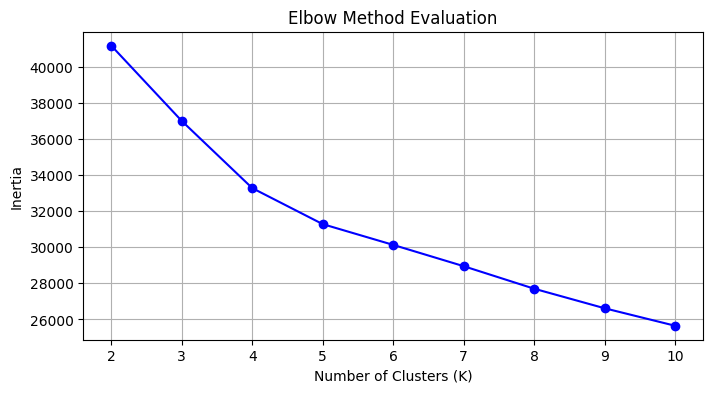

In [142]:
# Plotting the Elbow Curve to justify your final K choice
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, marker="o", color="b", linestyle="-")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method Evaluation")
plt.grid(True)
plt.xticks(k_range)
plt.savefig("elbow_method.png", dpi=150)
plt.show()

In [143]:
#Finding Optimal Number of Clusters using Silhouette Score
k_range = range(2, 11)
silhouette_scores = []
for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=300, random_state=42)
    labels = km.fit_predict(x_transform)
    score = silhouette_score(x_transform, labels)
    silhouette_scores.append(score)
    print(f'k={k:2d}, silhouette score: {score:.4f}')

#optimal K is the one with the highest silhouette score
best_k = list(k_range)[silhouette_scores.index(max(silhouette_scores))]
print(f'Optimal K based on silhouette score: {best_k}')

k= 2, silhouette score: 0.2341
k= 3, silhouette score: 0.1418
k= 4, silhouette score: 0.1581
k= 5, silhouette score: 0.1681
k= 6, silhouette score: 0.1621
k= 7, silhouette score: 0.1569
k= 8, silhouette score: 0.1460
k= 9, silhouette score: 0.1568
k=10, silhouette score: 0.1671
Optimal K based on silhouette score: 2


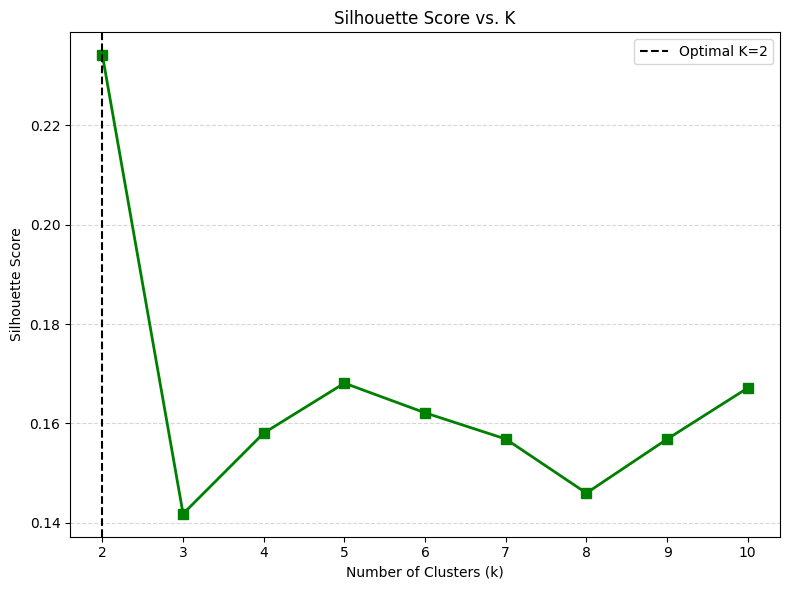

In [144]:
#Plotting Silhouette Scores for each K to visualize the optimal K choice
plt.figure(figsize=(8, 6))
plt.plot(k_range, silhouette_scores, marker='s', color='green', linewidth=2, markersize=7)
plt.axvline(best_k, color='black', linestyle='--', label=f'Optimal K={best_k}')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score') 
plt.title('Silhouette Score vs. K')
plt.xticks(k_range)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('K-means_Silhouette.png', dpi=150)
plt.show()

In [145]:
#Set best_k from Step 1 (elbow) confirmed by Step 2 (silhouette)
best_k = 2

km_final = KMeans(n_clusters=best_k, init='k-means++', n_init=10, max_iter=300, tol=1e-4, random_state=42)
km_final.fit(x_transform)

df['Cluster'] = km_final.labels_
print(f'Final K: {best_k}')
print(f'Final Inertia: {km_final.inertia_:.4f}')
print(f'Iteration taken: {km_final.n_iter_}')
print(f'\nCluster Counts:')
print(df['Cluster'].value_counts().sort_index())

Final K: 2
Final Inertia: 41174.6307
Iteration taken: 4

Cluster Counts:
Cluster
0    1875
1     375
Name: count, dtype: int64


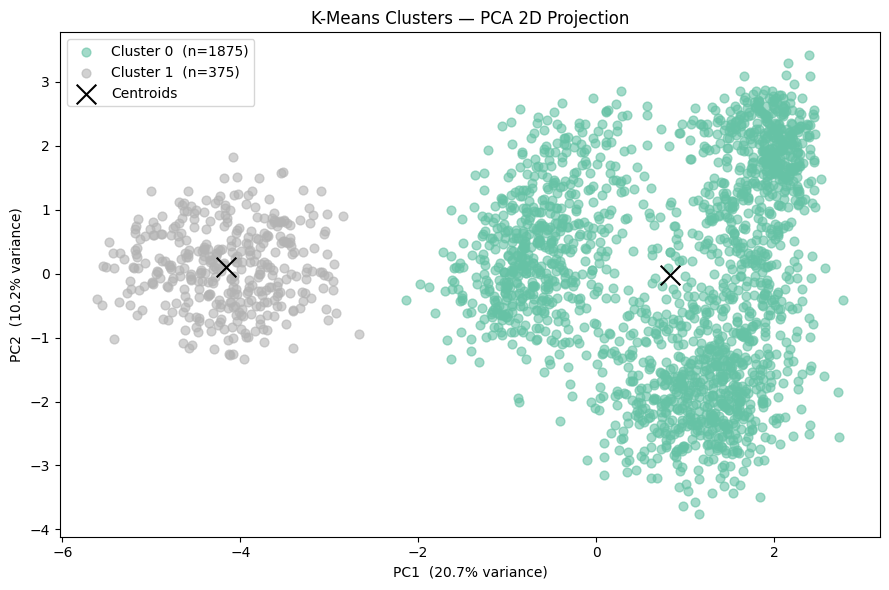

In [146]:
#Creating a 2D projection of the data using PCA for visualization
pca2 = PCA(n_components=2, random_state=42)
x_2d = pca2.fit_transform(x_transform)
 
# Centroids in PCA space
centroids_2d = pca2.transform(km_final.cluster_centers_)
 
plt.figure(figsize=(9, 6))
palette = plt.colormaps['Set2'].resampled(best_k)
for c in range(best_k):
    mask = df['Cluster'] == c
    plt.scatter(x_2d[mask, 0], x_2d[mask, 1],
                color=palette(c), alpha=0.6, s=40,
                label=f'Cluster {c}  (n={mask.sum()})')
 
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
            marker='x', s=200, c='black',
            zorder=5, label='Centroids')
plt.xlabel(f'PC1  ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2  ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title("K-Means Clusters — PCA 2D Projection")
plt.legend()
plt.tight_layout()
plt.savefig("kmeans_pca2d.png", dpi=150)
plt.show()


In [147]:
#Creating a Random Forest Classifier to predict failure_label using the original features.
rf = RandomForestClassifier(max_depth=10, min_samples_leaf=4, class_weight='balanced', random_state=42)
rf.fit(x_train, y_train)
#Predicting on the test set
y_pred = rf.predict(x_test)

In [148]:
#Evaluating the model on the test set
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
# Updated for Multiclass ROC AUC
print("ROC AUC Score:", roc_auc_score(y_test, rf.predict_proba(x_test), multi_class='ovr', average='macro'))


              precision    recall  f1-score   support

           0       0.99      1.00      0.99        80
           1       1.00      1.00      1.00       105
           2       1.00      1.00      1.00       115
           3       1.00      1.00      1.00        75
           4       1.00      0.99      0.99        75

    accuracy                           1.00       450
   macro avg       1.00      1.00      1.00       450
weighted avg       1.00      1.00      1.00       450

Accuracy: 0.9977777777777778
ROC AUC Score: 1.0


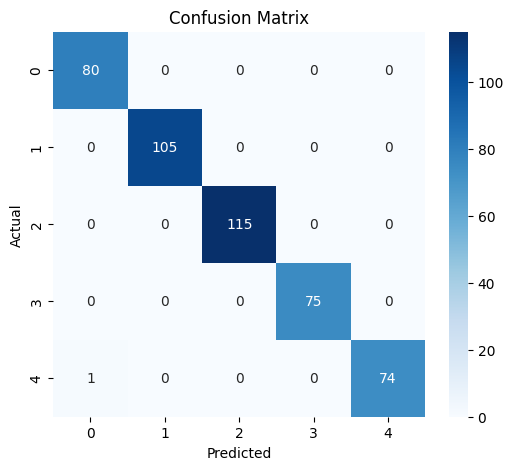

In [149]:
confusion_mtx = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [150]:
print("Number of features in data:", data.shape[1])
print("Length of feature importances:", len(rf.feature_importances_))

Number of features in data: 23
Length of feature importances: 22


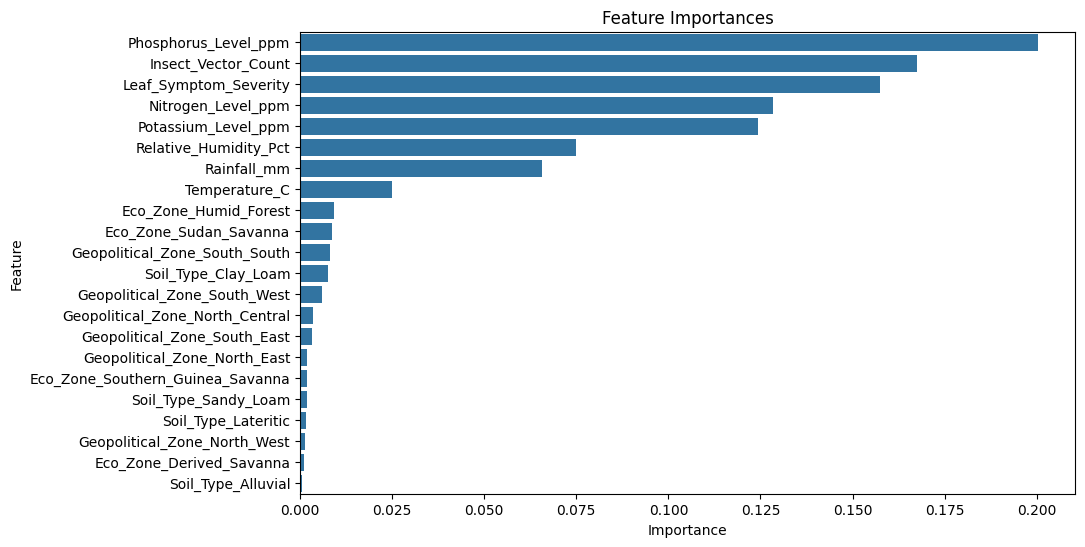

All Feature Importances:
                             Feature  Importance
4               Phosphorus_Level_ppm    0.200379
6                Insect_Vector_Count    0.167506
7              Leaf_Symptom_Severity    0.157528
3                 Nitrogen_Level_ppm    0.128293
5                Potassium_Level_ppm    0.124396
2              Relative_Humidity_Pct    0.074882
0                        Rainfall_mm    0.065720
1                      Temperature_C    0.024989
15             Eco_Zone_Humid_Forest    0.009294
17            Eco_Zone_Sudan_Savanna    0.008670
12     Geopolitical_Zone_South_South    0.008049
19               Soil_Type_Clay_Loam    0.007607
13      Geopolitical_Zone_South_West    0.005871
8    Geopolitical_Zone_North_Central    0.003402
11      Geopolitical_Zone_South_East    0.003140
9       Geopolitical_Zone_North_East    0.001980
16  Eco_Zone_Southern_Guinea_Savanna    0.001898
21              Soil_Type_Sandy_Loam    0.001888
20               Soil_Type_Lateritic    0.00

In [152]:
#Feature importance analysis
feature_names = data.drop(columns=['Disease_Class_Encoded']).columns
importance_df = pd.DataFrame({'Feature': feature_names,'Importance': rf.feature_importances_})
importance_df = (importance_df.sort_values('Importance', ascending=False))
#visualizing the top 10 most important features using a bar plot
plt.figure(figsize=(10,6))
sns.barplot(data=importance_df, x='Importance', y='Feature')
plt.title("Feature Importances")
plt.savefig("feature_importances.png", dpi=150, bbox_inches='tight')
plt.show()
print("All Feature Importances:")
print(importance_df)